In [1]:
from matplotlib import pyplot as plt
from matplotlib import colors
import numpy as np
from matplotlib.patches import Path, PathPatch
import pandas as pd
from shapely.geometry import Point, shape, Polygon
from shapely.ops import unary_union, cascaded_union
from geopandas.tools import sjoin
import geopandas as gpd
from netCDF4 import Dataset
from cartopy import crs as ccrs
from cartopy.io.shapereader import Reader
from sklearn.metrics import mean_squared_error
import scipy.stats as st
from sklearn.linear_model import LinearRegression
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap, BoundaryNorm

C:\Users\x12la\AppData\Local\Temp\ipykernel_13624\3882779582.py:8: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  from geopandas.tools import sjoin


<h1> Load data 

In [2]:
# CMAQ lat/lon datafile
d03 = Dataset('C:/Users/x12la/Desktop/latlon_ChicagoLADCO_d03.nc')
cmaq_lon,cmaq_lat = np.array(d03['lon']),np.array(d03['lat'])
cmaq_llat,cmaq_ulat,cmaq_llon,cmaq_ulon=cmaq_lat.min(), cmaq_lat.max(), cmaq_lon.min(), cmaq_lon.max()

In [3]:
#CMAP 7 counties surrounding Chicago/Cook County
cmap_cty = gpd.read_file('C:/Users/x12la/Desktop/Scripts/CMAP_cty.shp')
cmap_cty = cmap_cty.to_crs('EPSG:4326')

#primary roads
primary_roads = gpd.read_file('C:/Users/x12la/Desktop/Scripts/tl_2016_us_primaryroads.shp')
primary_roads = primary_roads.to_crs('EPSG:4326')

In [4]:
# Upload Aconc shapefiles
base = gpd.read_file('COMBINE_ACONC_BASE_JanJulAvg_D03_censustracts.shp')
base = base.to_crs('EPSG:4326')

idling = gpd.read_file('COMBINE_ACONC_LOCUSIdling_HDVSpatial_JanJulAvg_D03_censustracts.shp')
idling = idling.to_crs('EPSG:4326')

renewal = gpd.read_file('COMBINE_ACONC_Renewal_JanJulAvg_D03_censustracts.shp')
renewal = renewal.to_crs('EPSG:4326')

zeropre2010s =  gpd.read_file('COMBINE_ACONC_ZeroPre2010s_Annual2023_avg_censustracts.shp')
zeropre2010s = zeropre2010s.to_crs('EPSG:4326')

In [34]:
# ## Upload Aconc shapefiles
# base_o3 = gpd.read_file('MDA8O3_BASE_JanJulAvg_D03_censustracts.shp')
# base_o3 = base_o3.to_crs('EPSG:4326')

# idling_o3 = gpd.read_file('MDA8O3_LOCUSIdling_HDVSpatial_JanJulAvg_D03_censustracts.shp')
# idling_o3 = idling_o3.to_crs('EPSG:4326')

# renewal_o3 = gpd.read_file('MDA8O3_Renewal_JanJulAvg_D03_censustracts.shp')
# renewal_o3 = renewal_o3.to_crs('EPSG:4326')

zeropre2010s_o3 =  gpd.read_file('MDA8O3_ZeroPre2010_AnnualAvg_censustracts.shp')
zeropre2010s_o3 = zeropre2010s_o3.to_crs('EPSG:4326')

In [35]:
#Clip geopandas files to CMAP
cmap_roads = gpd.clip(primary_roads, cmap_cty.to_crs('EPSG:4326'))
cmap_base = gpd.clip(base, cmap_cty.to_crs('EPSG:4326'))
cmap_idling = gpd.clip(idling, cmap_cty.to_crs('EPSG:4326'))
cmap_renewal = gpd.clip(renewal, cmap_cty.to_crs('EPSG:4326'))
cmap_zeropre2010s = gpd.clip(zeropre2010s, cmap_cty.to_crs('EPSG:4326'))

cmap_base_o3 = gpd.clip(base_o3, cmap_cty.to_crs('EPSG:4326'))
cmap_idling_o3 = gpd.clip(idling_o3, cmap_cty.to_crs('EPSG:4326'))
cmap_renewal_o3 = gpd.clip(renewal_o3, cmap_cty.to_crs('EPSG:4326'))
cmap_zeropre2010s_o3 = gpd.clip(zeropre2010s_o3, cmap_cty.to_crs('EPSG:4326'))

<h1> Plot All 

C:\Users\x12la\AppData\Local\Temp\ipykernel_13624\3081522701.py:98: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap(plot_config[pol]["cmap_name"])(np.linspace(0, 1, N_BINS))


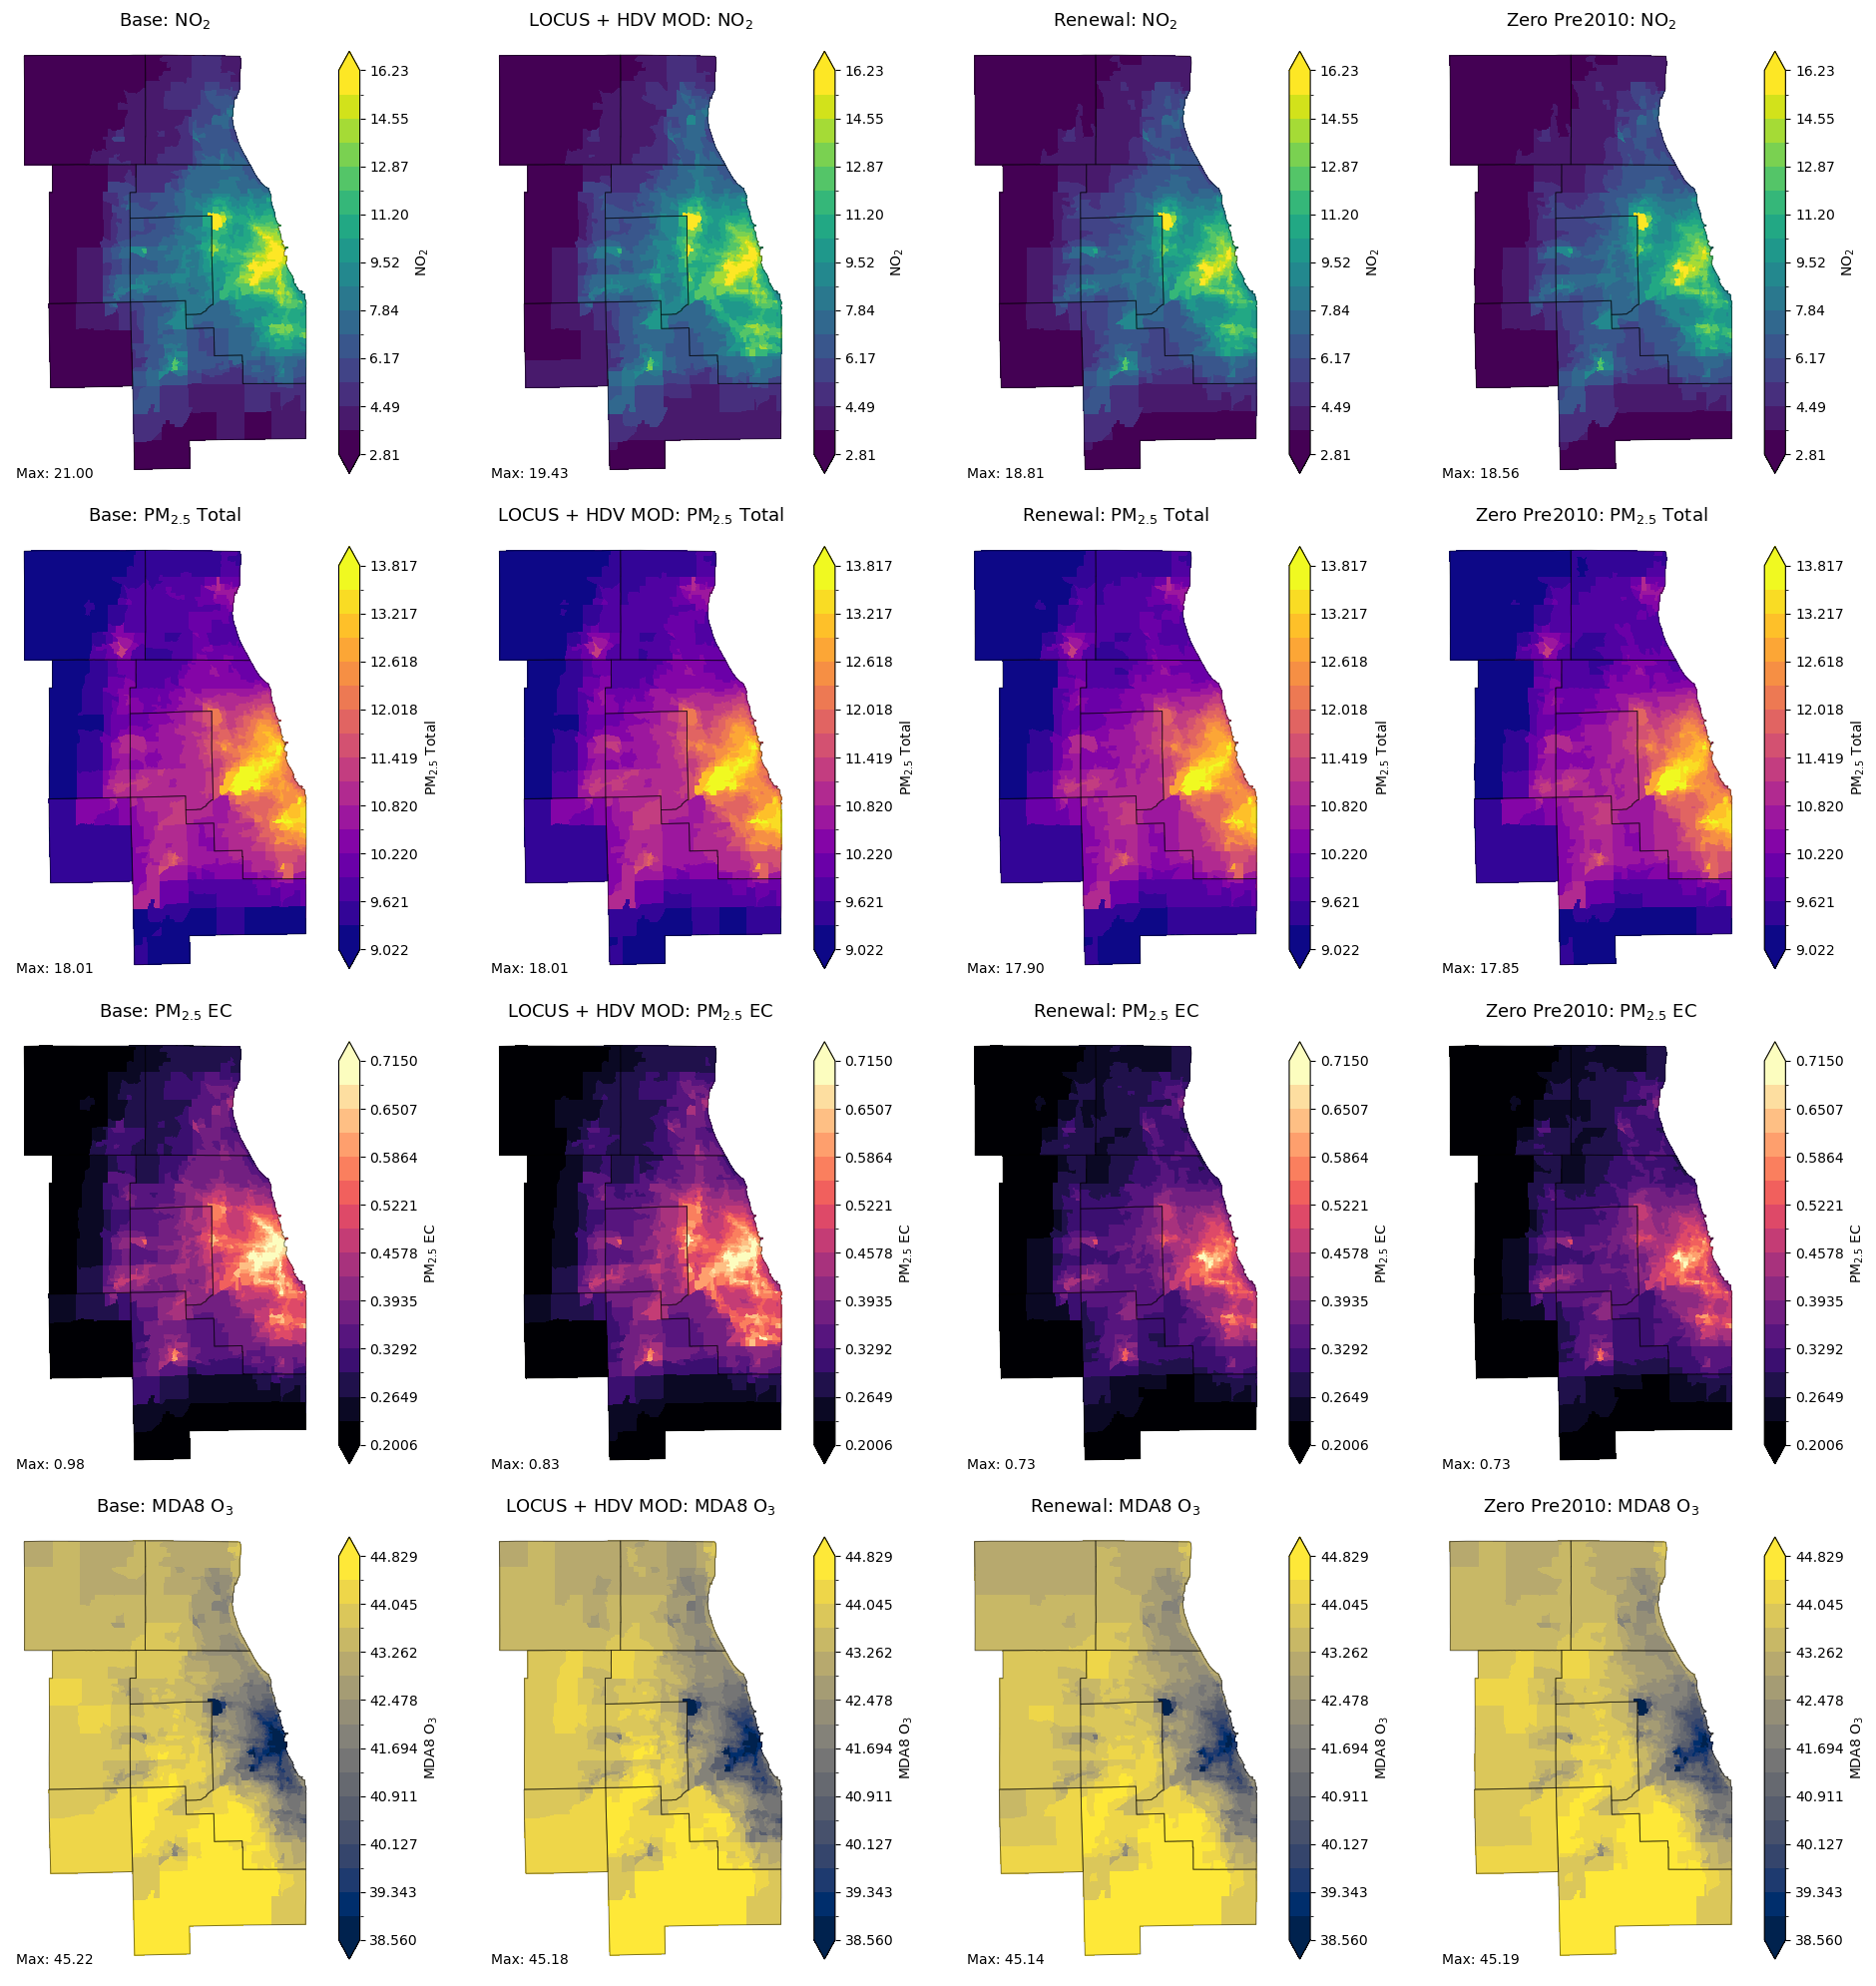

In [43]:
N_BINS = 16

# ---------------------------------------------------
# pollutant plotting setup
# ---------------------------------------------------
plot_config = {
    "NO2": {
        "cmap_name": "viridis",
        "title": "NO$_2$",
        "label": "NO$_2$",
        "column": "NO2",
    },
    "PM25_TOT": {
        "cmap_name": "plasma",
        "title": "PM$_{2.5}$ Total",
        "label": "PM$_{2.5}$ Total",
        "column": "PM25_TOT",
    },
    "PM25_EC": {
        "cmap_name": "magma",
        "title": "PM$_{2.5}$ EC",
        "label": "PM$_{2.5}$ EC",
        "column": "PM25_EC",
    },
    "O3": {
        "cmap_name": "cividis",
        "title": "MDA8 O$_3$",
        "label": "MDA8 O$_3$",
        "column": "O3",  
    },
}

pollutants = ["NO2", "PM25_TOT", "PM25_EC", "O3"]

# ---------------------------------------------------
# scenario GeoDataFrames by pollutant
# O3 uses the MDA8 O3-specific files
# ---------------------------------------------------
scenario_gdfs_by_pol = {
    "NO2": {
        "Base": cmap_base,
        "LOCUS + HDV MOD": cmap_idling,
        "Renewal": cmap_renewal,
        "Zero Pre2010": cmap_zeropre2010s,
    },
    "PM25_TOT": {
        "Base": cmap_base,
        "LOCUS + HDV MOD": cmap_idling,
        "Renewal": cmap_renewal,
        "Zero Pre2010": cmap_zeropre2010s,
    },
    "PM25_EC": {
        "Base": cmap_base,
        "LOCUS + HDV MOD": cmap_idling,
        "Renewal": cmap_renewal,
        "Zero Pre2010": cmap_zeropre2010s,
    },
    "O3": {
        "Base": cmap_base_o3,
        "LOCUS + HDV MOD": cmap_idling_o3,
        "Renewal": cmap_renewal_o3,
        "Zero Pre2010": cmap_zeropre2010s_o3,
    },
}

scenario_names = [
    "Base",
    "LOCUS + HDV MOD",
    "Renewal",
    "Zero Pre2010",
]

# ---------------------------------------------------
# build shared color style for each pollutant
# ---------------------------------------------------
pollutant_styles = {}

for pol in pollutants:
    vals_all = []
    col = plot_config[pol]["column"]

    for scen in scenario_names:
        gdf = scenario_gdfs_by_pol[pol][scen]

        vals = gdf[col].astype(float).to_numpy()
        vals = vals[np.isfinite(vals)]
        vals_all.append(vals)

    vals_all = np.concatenate(vals_all)

    vmin = np.quantile(vals_all, 0.01)
    vmax = np.quantile(vals_all, 0.99)

    if np.isclose(vmin, vmax):
        vmax = vmin + 1e-6

    cmap_disc = ListedColormap(
        plt.cm.get_cmap(plot_config[pol]["cmap_name"])(np.linspace(0, 1, N_BINS))
    )

    bounds = np.linspace(vmin, vmax, N_BINS + 1)
    norm = BoundaryNorm(bounds, cmap_disc.N)

    pollutant_styles[pol] = {
        "vmin": vmin,
        "vmax": vmax,
        "bounds": bounds,
        "cmap": cmap_disc,
        "norm": norm,
    }

# ---------------------------------------------------
# plot
# ---------------------------------------------------
fig, axs = plt.subplots(
    nrows=4,
    ncols=4,
    figsize=(20, 20),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

for i, pol in enumerate(pollutants):
    col = plot_config[pol]["column"]

    for j, scen in enumerate(scenario_names):
        ax = axs[i, j]
        gdf = scenario_gdfs_by_pol[pol][scen]

        style = pollutant_styles[pol]
        cmap_disc = style["cmap"]
        norm = style["norm"]
        bounds = style["bounds"]

        gdf.plot(
            column=col,
            ax=ax,
            cmap=cmap_disc,
            norm=norm,
            edgecolor="none",
            antialiased=False,
        )

        cmap_cty.boundary.plot(ax=ax, color="k", alpha=0.5, linewidth=0.7)

        ax.set_title(f"{scen}: {plot_config[pol]['title']}", fontsize=13)
        ax.set_axis_off()

        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_disc)
        sm._A = []

        cbar = fig.colorbar(
            sm,
            ax=ax,
            fraction=0.046,
            pad=0.04,
            boundaries=bounds,
            ticks=bounds[::2],
            spacing="proportional",
            extend="both",
        )

        cbar.set_label(plot_config[pol]["label"], fontsize=10)

        vals = gdf[col].astype(float).to_numpy()
        vals = vals[np.isfinite(vals)]

        vmax_panel = float(np.nanmax(vals))

        ax.text(
            0.02,
            0.02,
            f"Max: {vmax_panel:.2f}",
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=10,
            color="black",
            bbox=dict(
                facecolor="white",
                alpha=0.7,
                boxstyle="round,pad=0.25",
                linewidth=0,
            ),
        )

plt.tight_layout()
plt.show()

C:\Users\x12la\AppData\Local\Temp\ipykernel_13624\2886556193.py:74: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap(cfg["cmap_name"])(np.linspace(0, 1, N_BINS))
C:\Users\x12la\AppData\Local\Temp\ipykernel_13624\2886556193.py:122: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS))
C:\Users\x12la\AppData\Local\Temp\ipykernel_13624\2886556193.py:125: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap("bwr")(np.

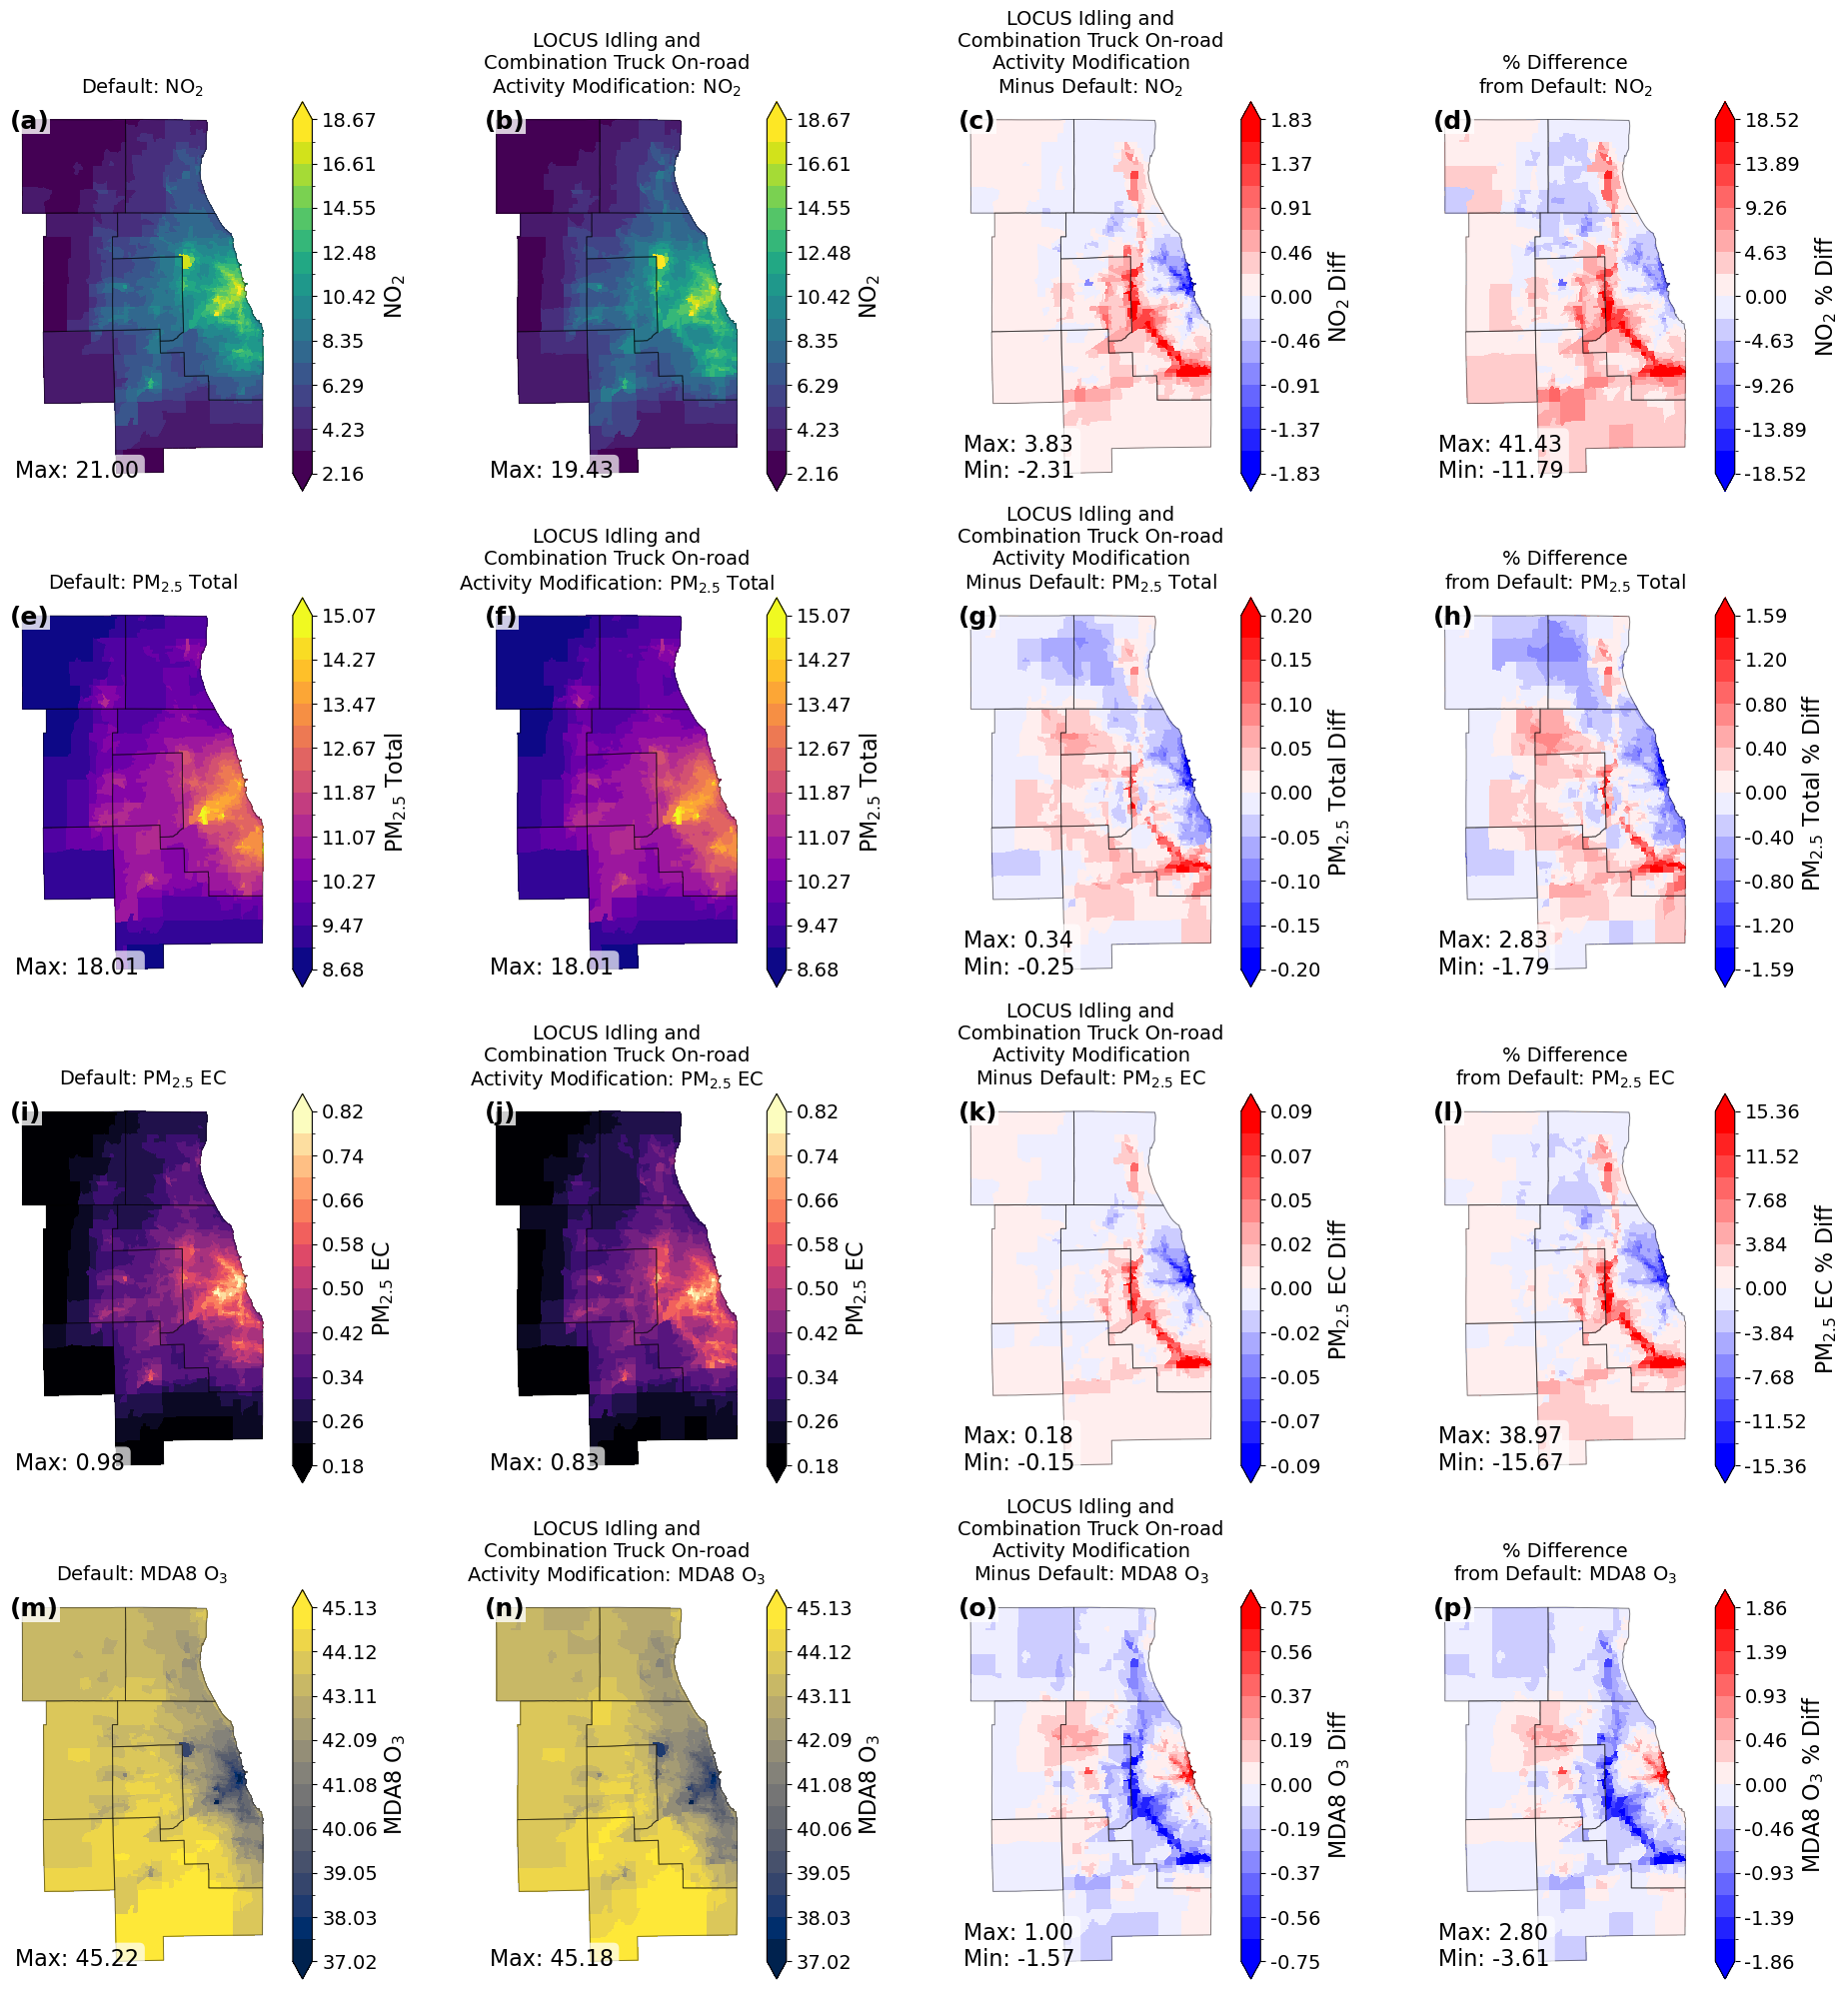

In [44]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.ticker import FormatStrFormatter
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs

N_BINS = 16

# ---------------------------------------------------
# pollutant plotting setup
# ---------------------------------------------------
plot_config = {
    "NO2": {
        "cmap_name": "viridis",
        "title": "NO$_2$",
        "label": "NO$_2$",
        "reference_gdf": cmap_base,
        "scenario_gdf": cmap_idling,
        "column": "NO2",
    },
    "PM25_TOT": {
        "cmap_name": "plasma",
        "title": "PM$_{2.5}$ Total",
        "label": "PM$_{2.5}$ Total",
        "reference_gdf": cmap_base,
        "scenario_gdf": cmap_idling,
        "column": "PM25_TOT",
    },
    "PM25_EC": {
        "cmap_name": "magma",
        "title": "PM$_{2.5}$ EC",
        "label": "PM$_{2.5}$ EC",
        "reference_gdf": cmap_base,
        "scenario_gdf": cmap_idling,
        "column": "PM25_EC",
    },
    "O3": {
        "cmap_name": "cividis",
        "title": "MDA8 O$_3$",
        "label": "MDA8 O$_3$",
        "reference_gdf": cmap_base_o3,
        "scenario_gdf": cmap_idling_o3,
        "column": "O3",  # change if your MDA8 O3 column has a different name
    },
}

pollutants = ["NO2", "PM25_TOT", "PM25_EC", "O3"]

# ---------------------------------------------------
# build styles for absolute panels: default + LOCUS
# ---------------------------------------------------
abs_styles = {}

for pol in pollutants:
    cfg = plot_config[pol]
    col = cfg["column"]

    vals_all = []

    for gdf in [cfg["reference_gdf"], cfg["scenario_gdf"]]:
        vals = gdf[col].astype(float).to_numpy()
        vals = vals[np.isfinite(vals)]
        vals_all.append(vals)

    vals_all = np.concatenate(vals_all)

    vmin = np.quantile(vals_all, 0.001)
    vmax = np.quantile(vals_all, 0.999)

    if np.isclose(vmin, vmax):
        vmax = vmin + 1e-6

    cmap_disc = ListedColormap(
        plt.cm.get_cmap(cfg["cmap_name"])(np.linspace(0, 1, N_BINS))
    )

    bounds = np.linspace(vmin, vmax, N_BINS + 1)
    norm = BoundaryNorm(bounds, cmap_disc.N)

    abs_styles[pol] = {
        "bounds": bounds,
        "cmap": cmap_disc,
        "norm": norm,
    }

# ---------------------------------------------------
# build styles for difference panels
#   col 3 = LOCUS - default
#   col 4 = % diff relative to default
# ---------------------------------------------------
diff_styles = {}

for pol in pollutants:
    cfg = plot_config[pol]
    col = cfg["column"]

    reference_vals = cfg["reference_gdf"][col].astype(float).to_numpy()
    scenario_vals = cfg["scenario_gdf"][col].astype(float).to_numpy()

    diff_vals = scenario_vals - reference_vals
    pct_vals = np.where(
        reference_vals != 0,
        (diff_vals / reference_vals) * 100.0,
        np.nan,
    )

    diff_vals_finite = diff_vals[np.isfinite(diff_vals)]
    pct_vals_finite = pct_vals[np.isfinite(pct_vals)]

    diff_lim = np.quantile(np.abs(diff_vals_finite), 0.99)
    pct_lim = np.quantile(np.abs(pct_vals_finite), 0.99)

    if np.isclose(diff_lim, 0):
        diff_lim = 1e-6
    if np.isclose(pct_lim, 0):
        pct_lim = 1e-6

    diff_bounds = np.linspace(-diff_lim, diff_lim, N_BINS + 1)
    pct_bounds = np.linspace(-pct_lim, pct_lim, N_BINS + 1)

    diff_cmap = ListedColormap(
        plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS))
    )
    pct_cmap = ListedColormap(
        plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS))
    )

    diff_styles[pol] = {
        "diff_bounds": diff_bounds,
        "diff_cmap": diff_cmap,
        "diff_norm": BoundaryNorm(diff_bounds, diff_cmap.N),
        "pct_bounds": pct_bounds,
        "pct_cmap": pct_cmap,
        "pct_norm": BoundaryNorm(pct_bounds, pct_cmap.N),
    }

# ---------------------------------------------------
# make plotting GeoDataFrames
# ---------------------------------------------------
scenario_names = [
    "Default",
    "LOCUS Idling and\nCombination Truck On-road\nActivity Modification",
    "LOCUS Idling and\nCombination Truck On-road\nActivity Modification\nMinus Default",
    "% Difference\nfrom Default",
]

scenario_gdfs_by_pol = {}

for pol in pollutants:
    cfg = plot_config[pol]
    col = cfg["column"]

    plot_reference = cfg["reference_gdf"].copy()
    plot_scenario = cfg["scenario_gdf"].copy()
    plot_diff = cfg["scenario_gdf"].copy()
    plot_pct = cfg["scenario_gdf"].copy()

    plot_reference[pol] = plot_reference[col].astype(float)
    plot_scenario[pol] = plot_scenario[col].astype(float)

    plot_diff[pol] = (
        cfg["scenario_gdf"][col].astype(float)
        - cfg["reference_gdf"][col].astype(float)
    )

    plot_pct[pol] = np.where(
        cfg["reference_gdf"][col].astype(float) != 0,
        (
            (
                cfg["scenario_gdf"][col].astype(float)
                - cfg["reference_gdf"][col].astype(float)
            )
            / cfg["reference_gdf"][col].astype(float)
        )
        * 100.0,
        np.nan,
    )

    scenario_gdfs_by_pol[pol] = {
        scenario_names[0]: plot_reference,
        scenario_names[1]: plot_scenario,
        scenario_names[2]: plot_diff,
        scenario_names[3]: plot_pct,
    }

# ---------------------------------------------------
# plot
# ---------------------------------------------------
fig, axs = plt.subplots(
    nrows=len(pollutants),
    ncols=4,
    figsize=(20, 20),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

for i, pol in enumerate(pollutants):
    for j, scen in enumerate(scenario_names):
        ax = axs[i, j]

        panel_label = f"({chr(97 + i * 4 + j)})"

        ax.text(
            0.001,
            0.98,
            panel_label,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=18,
            fontweight="bold",
            bbox=dict(
                facecolor="white",
                alpha=0.8,
                edgecolor="none",
                pad=0.2,
            ),
        )

        gdf = scenario_gdfs_by_pol[pol][scen]

        if j in [0, 1]:
            style = abs_styles[pol]
            cmap_disc = style["cmap"]
            norm = style["norm"]
            bounds = style["bounds"]
            extend_opt = "both"

        elif j == 2:
            style = diff_styles[pol]
            cmap_disc = style["diff_cmap"]
            norm = style["diff_norm"]
            bounds = style["diff_bounds"]
            extend_opt = "both"

        else:
            style = diff_styles[pol]
            cmap_disc = style["pct_cmap"]
            norm = style["pct_norm"]
            bounds = style["pct_bounds"]
            extend_opt = "both"

        gdf.plot(
            column=pol,
            ax=ax,
            cmap=cmap_disc,
            norm=norm,
            edgecolor="none",
            antialiased=False,
        )

        cmap_cty.boundary.plot(ax=ax, color="k", alpha=0.5, linewidth=0.7)

        ax.set_title(f"{scen}: {plot_config[pol]['title']}", fontsize=14)
        ax.set_axis_off()

        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_disc)
        sm._A = []

        cbar = fig.colorbar(
            sm,
            ax=ax,
            fraction=0.046,
            pad=0.04,
            boundaries=bounds,
            ticks=bounds[::2],
            spacing="proportional",
            extend=extend_opt,
        )

        cbar.ax.tick_params(labelsize=14)
        cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

        if j == 3:
            cbar.set_label(f"{plot_config[pol]['label']} % Diff", fontsize=16)
        elif j == 2:
            cbar.set_label(f"{plot_config[pol]['label']} Diff", fontsize=16)
        else:
            cbar.set_label(plot_config[pol]["label"], fontsize=16)

        vals = gdf[pol].astype(float).to_numpy()
        vals = vals[np.isfinite(vals)]

        vmax_panel = float(np.nanmax(vals))
        vmin_panel = float(np.nanmin(vals))

        if j in [0, 1]:
            annot_text = f"Max: {vmax_panel:.2f}"
        else:
            annot_text = f"Max: {vmax_panel:.2f}\nMin: {vmin_panel:.2f}"

        ax.text(
            0.02,
            0.02,
            annot_text,
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=16,
            color="black",
            bbox=dict(
                facecolor="white",
                alpha=0.7,
                boxstyle="round,pad=0.25",
                linewidth=0,
            ),
        )

plt.savefig("Default_LOCUS_GriddedAirPoll_All.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

C:\Users\x12la\AppData\Local\Temp\ipykernel_13624\1699469925.py:68: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap(cfg["cmap_name"])(np.linspace(0, 1, N_BINS))
C:\Users\x12la\AppData\Local\Temp\ipykernel_13624\1699469925.py:118: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS))
C:\Users\x12la\AppData\Local\Temp\ipykernel_13624\1699469925.py:121: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap("bwr")(np.

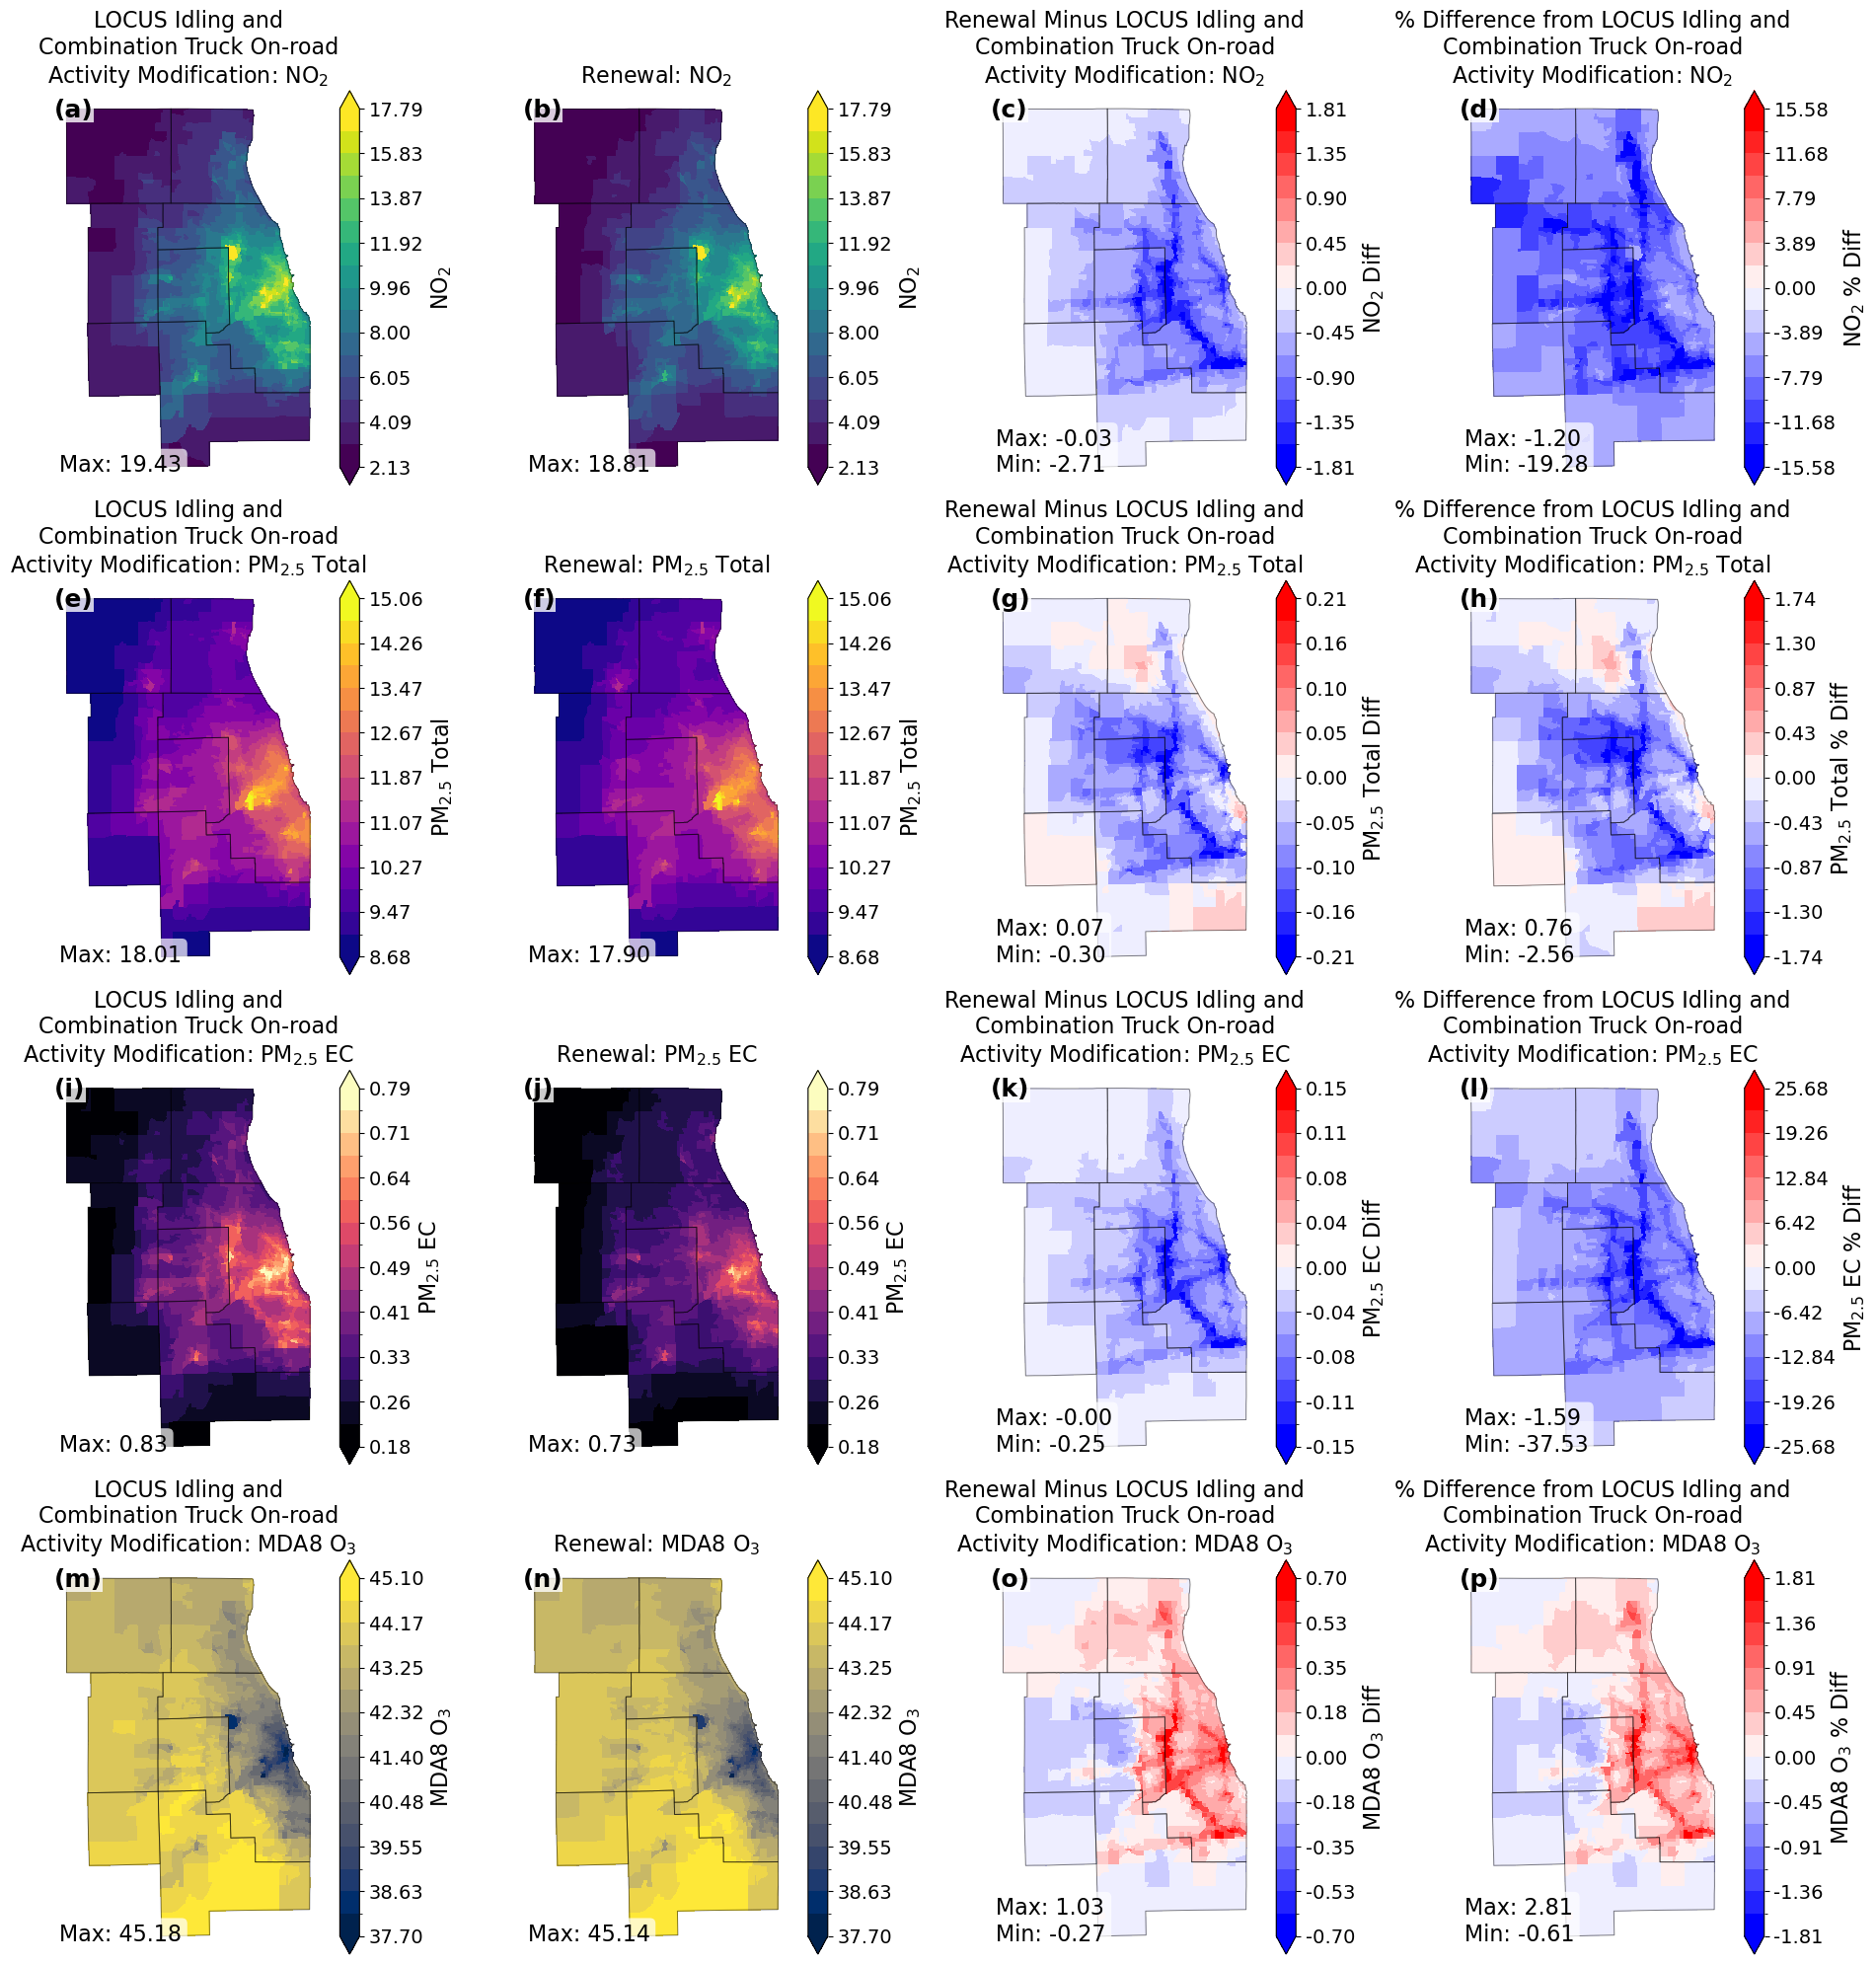

In [45]:
N_BINS = 16

# ---------------------------------------------------
# pollutant plotting setup
# ---------------------------------------------------
plot_config = {
    "NO2": {
        "cmap_name": "viridis",
        "title": "NO$_2$",
        "label": "NO$_2$",
        "reference_gdf": cmap_idling,
        "scenario_gdf": cmap_renewal,
        "column": "NO2",
    },
    "PM25_TOT": {
        "cmap_name": "plasma",
        "title": "PM$_{2.5}$ Total",
        "label": "PM$_{2.5}$ Total",
        "reference_gdf": cmap_idling,
        "scenario_gdf": cmap_renewal,
        "column": "PM25_TOT",
    },
    "PM25_EC": {
        "cmap_name": "magma",
        "title": "PM$_{2.5}$ EC",
        "label": "PM$_{2.5}$ EC",
        "reference_gdf": cmap_idling,
        "scenario_gdf": cmap_renewal,
        "column": "PM25_EC",
    },
    "O3": {
        "cmap_name": "cividis",
        "title": "MDA8 O$_3$",
        "label": "MDA8 O$_3$",
        "reference_gdf": cmap_idling_o3,
        "scenario_gdf": cmap_renewal_o3,
        "column": "O3",  # change if your MDA8 O3 column has a different name
    },
}

pollutants = ["NO2", "PM25_TOT", "PM25_EC", "O3"]

# ---------------------------------------------------
# build styles for absolute panels: LOCUS + renewal
# ---------------------------------------------------
abs_styles = {}

for pol in pollutants:
    cfg = plot_config[pol]
    col = cfg["column"]

    vals_all = []

    for gdf in [cfg["reference_gdf"], cfg["scenario_gdf"]]:
        vals = gdf[col].astype(float).to_numpy()
        vals = vals[np.isfinite(vals)]
        vals_all.append(vals)

    vals_all = np.concatenate(vals_all)

    vmin = np.quantile(vals_all, 0.001)
    vmax = np.quantile(vals_all, 0.999)

    if np.isclose(vmin, vmax):
        vmax = vmin + 1e-6

    cmap_disc = ListedColormap(
        plt.cm.get_cmap(cfg["cmap_name"])(np.linspace(0, 1, N_BINS))
    )

    bounds = np.linspace(vmin, vmax, N_BINS + 1)
    norm = BoundaryNorm(bounds, cmap_disc.N)

    abs_styles[pol] = {
        "vmin": vmin,
        "vmax": vmax,
        "bounds": bounds,
        "cmap": cmap_disc,
        "norm": norm,
    }

# ---------------------------------------------------
# build styles for difference panels
#   col 3 = renewal - LOCUS
#   col 4 = % diff relative to LOCUS
# ---------------------------------------------------
diff_styles = {}

for pol in pollutants:
    cfg = plot_config[pol]
    col = cfg["column"]

    reference_vals = cfg["reference_gdf"][col].astype(float).to_numpy()
    scenario_vals = cfg["scenario_gdf"][col].astype(float).to_numpy()

    diff_vals = scenario_vals - reference_vals
    pct_vals = np.where(
        reference_vals != 0,
        (diff_vals / reference_vals) * 100.0,
        np.nan,
    )

    diff_vals_finite = diff_vals[np.isfinite(diff_vals)]
    pct_vals_finite = pct_vals[np.isfinite(pct_vals)]

    diff_lim = np.quantile(np.abs(diff_vals_finite), 0.99)
    pct_lim = np.quantile(np.abs(pct_vals_finite), 0.99)

    if np.isclose(diff_lim, 0):
        diff_lim = 1e-6
    if np.isclose(pct_lim, 0):
        pct_lim = 1e-6

    diff_bounds = np.linspace(-diff_lim, diff_lim, N_BINS + 1)
    pct_bounds = np.linspace(-pct_lim, pct_lim, N_BINS + 1)

    diff_cmap = ListedColormap(
        plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS))
    )
    pct_cmap = ListedColormap(
        plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS))
    )

    diff_styles[pol] = {
        "diff_bounds": diff_bounds,
        "diff_cmap": diff_cmap,
        "diff_norm": BoundaryNorm(diff_bounds, diff_cmap.N),
        "pct_bounds": pct_bounds,
        "pct_cmap": pct_cmap,
        "pct_norm": BoundaryNorm(pct_bounds, pct_cmap.N),
    }

# ---------------------------------------------------
# make plotting GeoDataFrames
# ---------------------------------------------------
scenario_names = [
    "LOCUS Idling and\nCombination Truck On-road\nActivity Modification",
    "Renewal",
    "Renewal Minus LOCUS Idling and\nCombination Truck On-road\nActivity Modification",
    "% Difference from LOCUS Idling and\nCombination Truck On-road\nActivity Modification",
]

scenario_gdfs_by_pol = {}

for pol in pollutants:
    cfg = plot_config[pol]
    col = cfg["column"]

    plot_reference = cfg["reference_gdf"].copy()
    plot_scenario = cfg["scenario_gdf"].copy()
    plot_diff = cfg["scenario_gdf"].copy()
    plot_pct = cfg["scenario_gdf"].copy()

    plot_reference[pol] = plot_reference[col].astype(float)
    plot_scenario[pol] = plot_scenario[col].astype(float)

    plot_diff[pol] = (
        cfg["scenario_gdf"][col].astype(float)
        - cfg["reference_gdf"][col].astype(float)
    )

    plot_pct[pol] = np.where(
        cfg["reference_gdf"][col].astype(float) != 0,
        (
            (
                cfg["scenario_gdf"][col].astype(float)
                - cfg["reference_gdf"][col].astype(float)
            )
            / cfg["reference_gdf"][col].astype(float)
        )
        * 100.0,
        np.nan,
    )

    scenario_gdfs_by_pol[pol] = {
        scenario_names[0]: plot_reference,
        scenario_names[1]: plot_scenario,
        scenario_names[2]: plot_diff,
        scenario_names[3]: plot_pct,
    }

# ---------------------------------------------------
# plot
# ---------------------------------------------------
fig, axs = plt.subplots(
    nrows=len(pollutants),
    ncols=4,
    figsize=(20, 20),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

for i, pol in enumerate(pollutants):
    for j, scen in enumerate(scenario_names):
        ax = axs[i, j]

        panel_label = f"({chr(97 + i * 4 + j)})"

        ax.text(
            0.001,
            0.98,
            panel_label,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=18,
            fontweight="bold",
            bbox=dict(
                facecolor="white",
                alpha=0.8,
                edgecolor="none",
                pad=0.2,
            ),
        )

        gdf = scenario_gdfs_by_pol[pol][scen]

        if j in [0, 1]:
            style = abs_styles[pol]
            cmap_disc = style["cmap"]
            norm = style["norm"]
            bounds = style["bounds"]
            extend_opt = "both"

        elif j == 2:
            style = diff_styles[pol]
            cmap_disc = style["diff_cmap"]
            norm = style["diff_norm"]
            bounds = style["diff_bounds"]
            extend_opt = "both"

        else:
            style = diff_styles[pol]
            cmap_disc = style["pct_cmap"]
            norm = style["pct_norm"]
            bounds = style["pct_bounds"]
            extend_opt = "both"

        gdf.plot(
            column=pol,
            ax=ax,
            cmap=cmap_disc,
            norm=norm,
            edgecolor="none",
            antialiased=False,
        )

        cmap_cty.boundary.plot(ax=ax, color="k", alpha=0.5, linewidth=0.7)

        ax.set_title(f"{scen}: {plot_config[pol]['title']}", fontsize=16)
        ax.set_axis_off()

        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_disc)
        sm._A = []

        cbar = fig.colorbar(
            sm,
            ax=ax,
            fraction=0.046,
            pad=0.04,
            boundaries=bounds,
            ticks=bounds[::2],
            spacing="proportional",
            extend=extend_opt,
        )

        cbar.ax.tick_params(labelsize=14)
        cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

        if j == 3:
            cbar.set_label(f"{plot_config[pol]['label']} % Diff", fontsize=16)
        elif j == 2:
            cbar.set_label(f"{plot_config[pol]['label']} Diff", fontsize=16)
        else:
            cbar.set_label(plot_config[pol]["label"], fontsize=16)

        vals = gdf[pol].astype(float).to_numpy()
        vals = vals[np.isfinite(vals)]

        vmax_panel = float(np.nanmax(vals))
        vmin_panel = float(np.nanmin(vals))

        if j in [0, 1]:
            annot_text = f"Max: {vmax_panel:.2f}"
        else:
            annot_text = f"Max: {vmax_panel:.2f}\nMin: {vmin_panel:.2f}"

        ax.text(
            0.02,
            0.02,
            annot_text,
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=16,
            color="black",
            bbox=dict(
                facecolor="white",
                alpha=0.7,
                boxstyle="round,pad=0.25",
                linewidth=0,
            ),
        )

plt.savefig("LOCUS_Renewal_GriddedAirPoll_All.png", bbox_inches="tight")
plt.tight_layout()
plt.show()

C:\Users\x12la\AppData\Local\Temp\ipykernel_13624\122396049.py:68: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap(cfg["cmap_name"])(np.linspace(0, 1, N_BINS))
C:\Users\x12la\AppData\Local\Temp\ipykernel_13624\122396049.py:116: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS))
C:\Users\x12la\AppData\Local\Temp\ipykernel_13624\122396049.py:119: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap("bwr")(np.lin

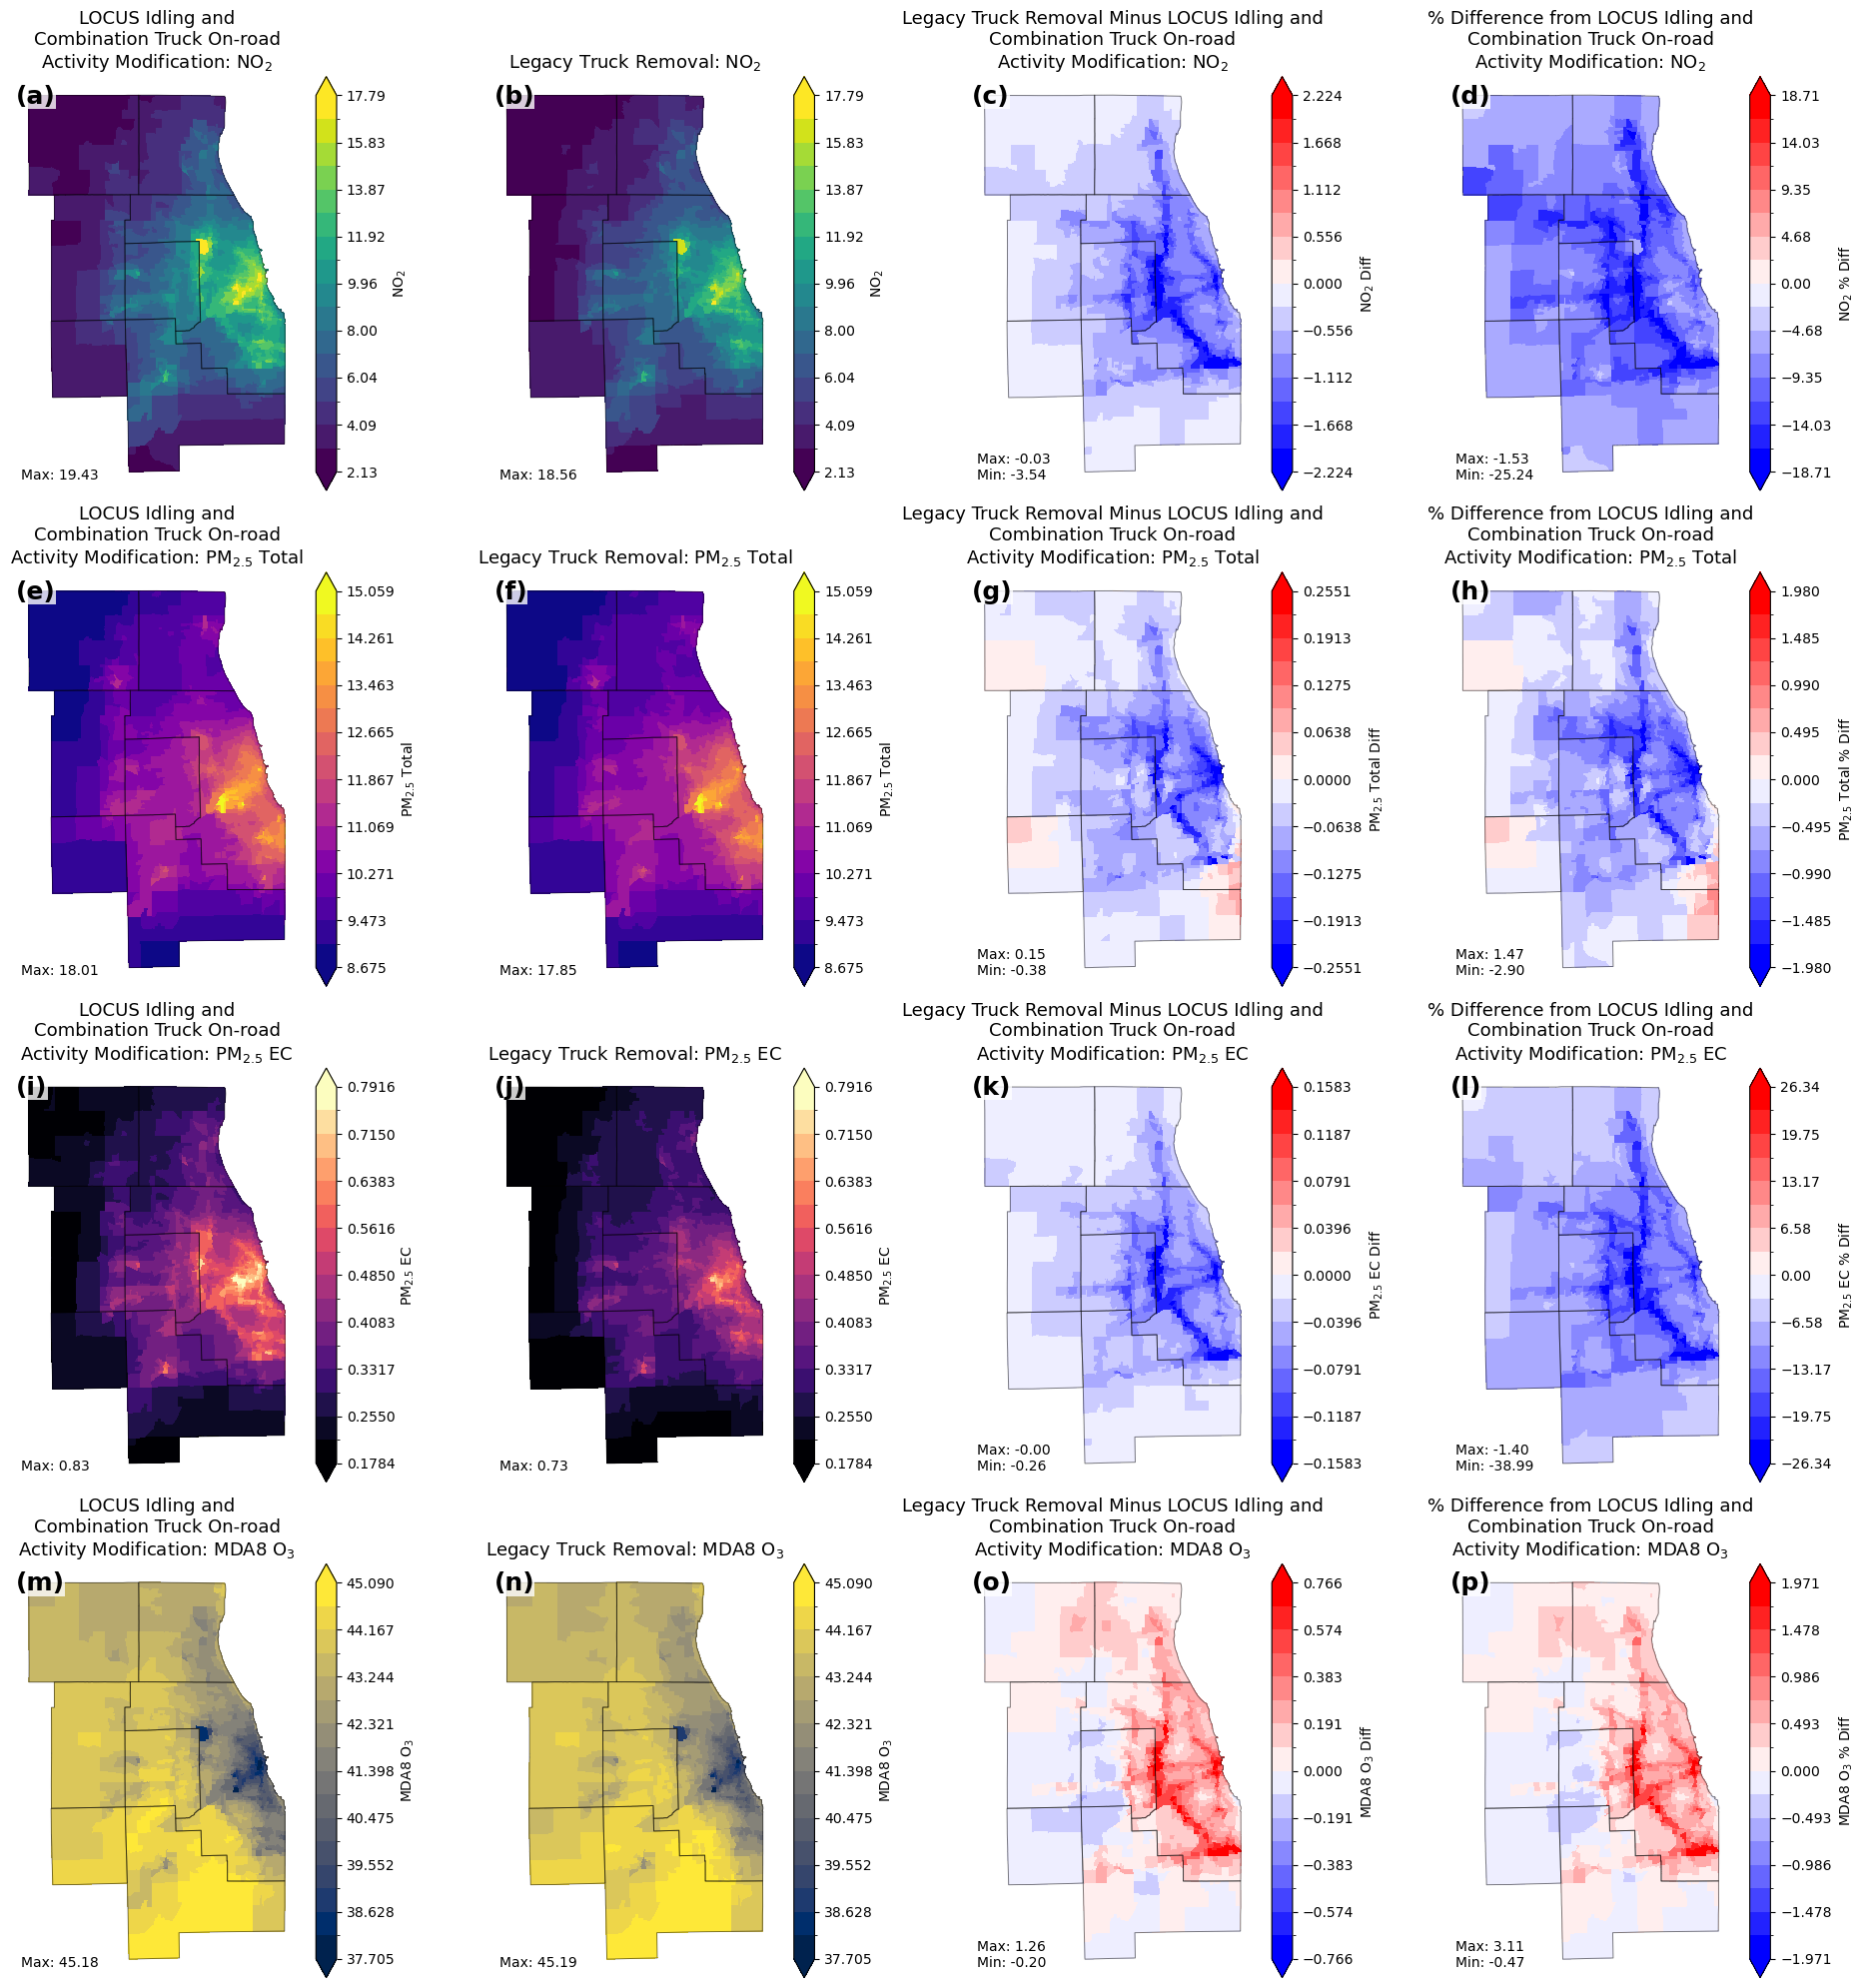

In [46]:
N_BINS = 16

# ---------------------------------------------------
# pollutant plotting setup
# ---------------------------------------------------
plot_config = {
    "NO2": {
        "cmap_name": "viridis",
        "title": "NO$_2$",
        "label": "NO$_2$",
        "reference_gdf": cmap_idling,
        "scenario_gdf": cmap_zeropre2010s,
        "column": "NO2",
    },
    "PM25_TOT": {
        "cmap_name": "plasma",
        "title": "PM$_{2.5}$ Total",
        "label": "PM$_{2.5}$ Total",
        "reference_gdf": cmap_idling,
        "scenario_gdf": cmap_zeropre2010s,
        "column": "PM25_TOT",
    },
    "PM25_EC": {
        "cmap_name": "magma",
        "title": "PM$_{2.5}$ EC",
        "label": "PM$_{2.5}$ EC",
        "reference_gdf": cmap_idling,
        "scenario_gdf": cmap_zeropre2010s,
        "column": "PM25_EC",
    },
    "O3": {
        "cmap_name": "cividis",
        "title": "MDA8 O$_3$",
        "label": "MDA8 O$_3$",
        "reference_gdf": cmap_idling_o3,
        "scenario_gdf": cmap_zeropre2010s_o3,
        "column": "O3",  # change if your MDA8 O3 column has a different name
    },
}

pollutants = ["NO2", "PM25_TOT", "PM25_EC", "O3"]

# ---------------------------------------------------
# build styles for absolute panels: LOCUS + legacy removal
# ---------------------------------------------------
abs_styles = {}

for pol in pollutants:
    cfg = plot_config[pol]
    col = cfg["column"]

    vals_all = []

    for gdf in [cfg["reference_gdf"], cfg["scenario_gdf"]]:
        vals = gdf[col].astype(float).to_numpy()
        vals = vals[np.isfinite(vals)]
        vals_all.append(vals)

    vals_all = np.concatenate(vals_all)

    vmin = np.quantile(vals_all, 0.001)
    vmax = np.quantile(vals_all, 0.999)

    if np.isclose(vmin, vmax):
        vmax = vmin + 1e-6

    cmap_disc = ListedColormap(
        plt.cm.get_cmap(cfg["cmap_name"])(np.linspace(0, 1, N_BINS))
    )

    bounds = np.linspace(vmin, vmax, N_BINS + 1)
    norm = BoundaryNorm(bounds, cmap_disc.N)

    abs_styles[pol] = {
        "bounds": bounds,
        "cmap": cmap_disc,
        "norm": norm,
    }

# ---------------------------------------------------
# build styles for difference panels
#   col 3 = legacy removal - LOCUS
#   col 4 = % diff relative to LOCUS
# ---------------------------------------------------
diff_styles = {}

for pol in pollutants:
    cfg = plot_config[pol]
    col = cfg["column"]

    reference_vals = cfg["reference_gdf"][col].astype(float).to_numpy()
    scenario_vals = cfg["scenario_gdf"][col].astype(float).to_numpy()

    diff_vals = scenario_vals - reference_vals
    pct_vals = np.where(
        reference_vals != 0,
        (diff_vals / reference_vals) * 100.0,
        np.nan,
    )

    diff_vals_finite = diff_vals[np.isfinite(diff_vals)]
    pct_vals_finite = pct_vals[np.isfinite(pct_vals)]

    diff_lim = np.quantile(np.abs(diff_vals_finite), 0.99)
    pct_lim = np.quantile(np.abs(pct_vals_finite), 0.99)

    if np.isclose(diff_lim, 0):
        diff_lim = 1e-6
    if np.isclose(pct_lim, 0):
        pct_lim = 1e-6

    diff_bounds = np.linspace(-diff_lim, diff_lim, N_BINS + 1)
    pct_bounds = np.linspace(-pct_lim, pct_lim, N_BINS + 1)

    diff_cmap = ListedColormap(
        plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS))
    )
    pct_cmap = ListedColormap(
        plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS))
    )

    diff_styles[pol] = {
        "diff_bounds": diff_bounds,
        "diff_cmap": diff_cmap,
        "diff_norm": BoundaryNorm(diff_bounds, diff_cmap.N),
        "pct_bounds": pct_bounds,
        "pct_cmap": pct_cmap,
        "pct_norm": BoundaryNorm(pct_bounds, pct_cmap.N),
    }

# ---------------------------------------------------
# make plotting GeoDataFrames
# ---------------------------------------------------
scenario_names = [
    "LOCUS Idling and\nCombination Truck On-road\nActivity Modification",
    "Legacy Truck Removal",
    "Legacy Truck Removal Minus LOCUS Idling and\nCombination Truck On-road\nActivity Modification",
    "% Difference from LOCUS Idling and\nCombination Truck On-road\nActivity Modification",
]

scenario_gdfs_by_pol = {}

for pol in pollutants:
    cfg = plot_config[pol]
    col = cfg["column"]

    plot_reference = cfg["reference_gdf"].copy()
    plot_scenario = cfg["scenario_gdf"].copy()
    plot_diff = cfg["scenario_gdf"].copy()
    plot_pct = cfg["scenario_gdf"].copy()

    plot_reference[pol] = plot_reference[col].astype(float)
    plot_scenario[pol] = plot_scenario[col].astype(float)

    plot_diff[pol] = (
        cfg["scenario_gdf"][col].astype(float)
        - cfg["reference_gdf"][col].astype(float)
    )

    plot_pct[pol] = np.where(
        cfg["reference_gdf"][col].astype(float) != 0,
        (
            (
                cfg["scenario_gdf"][col].astype(float)
                - cfg["reference_gdf"][col].astype(float)
            )
            / cfg["reference_gdf"][col].astype(float)
        )
        * 100.0,
        np.nan,
    )

    scenario_gdfs_by_pol[pol] = {
        scenario_names[0]: plot_reference,
        scenario_names[1]: plot_scenario,
        scenario_names[2]: plot_diff,
        scenario_names[3]: plot_pct,
    }

# ---------------------------------------------------
# plot
# ---------------------------------------------------
fig, axs = plt.subplots(
    nrows=len(pollutants),
    ncols=4,
    figsize=(20, 20),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

for i, pol in enumerate(pollutants):
    for j, scen in enumerate(scenario_names):
        ax = axs[i, j]

        panel_label = f"({chr(97 + i * 4 + j)})"

        ax.text(
            0.001,
            0.98,
            panel_label,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=18,
            fontweight="bold",
            bbox=dict(
                facecolor="white",
                alpha=0.8,
                edgecolor="none",
                pad=0.2,
            ),
        )

        gdf = scenario_gdfs_by_pol[pol][scen]

        if j in [0, 1]:
            style = abs_styles[pol]
            cmap_disc = style["cmap"]
            norm = style["norm"]
            bounds = style["bounds"]

        elif j == 2:
            style = diff_styles[pol]
            cmap_disc = style["diff_cmap"]
            norm = style["diff_norm"]
            bounds = style["diff_bounds"]

        else:
            style = diff_styles[pol]
            cmap_disc = style["pct_cmap"]
            norm = style["pct_norm"]
            bounds = style["pct_bounds"]

        gdf.plot(
            column=pol,
            ax=ax,
            cmap=cmap_disc,
            norm=norm,
            edgecolor="none",
            antialiased=False,
        )

        cmap_cty.boundary.plot(ax=ax, color="k", alpha=0.5, linewidth=0.7)

        ax.set_title(f"{scen}: {plot_config[pol]['title']}", fontsize=13)
        ax.set_axis_off()

        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_disc)
        sm._A = []

        cbar = fig.colorbar(
            sm,
            ax=ax,
            fraction=0.046,
            pad=0.04,
            boundaries=bounds,
            ticks=bounds[::2],
            spacing="proportional",
            extend="both",
        )

        if j == 3:
            cbar.set_label(f"{plot_config[pol]['label']} % Diff", fontsize=10)
        elif j == 2:
            cbar.set_label(f"{plot_config[pol]['label']} Diff", fontsize=10)
        else:
            cbar.set_label(plot_config[pol]["label"], fontsize=10)

        vals = gdf[pol].astype(float).to_numpy()
        vals = vals[np.isfinite(vals)]

        vmax_panel = float(np.nanmax(vals))
        vmin_panel = float(np.nanmin(vals))

        if j in [0, 1]:
            txt = f"Max: {vmax_panel:.2f}"
        else:
            txt = f"Max: {vmax_panel:.2f}\nMin: {vmin_panel:.2f}"

        ax.text(
            0.02,
            0.02,
            txt,
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=10,
            bbox=dict(
                facecolor="white",
                alpha=0.7,
                boxstyle="round,pad=0.25",
                linewidth=0,
            ),
        )

plt.tight_layout()
plt.show()

C:\Users\x12la\AppData\Local\Temp\ipykernel_13624\832953283.py:67: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap(cfg["cmap_name"])(np.linspace(0, 1, N_BINS))
C:\Users\x12la\AppData\Local\Temp\ipykernel_13624\832953283.py:110: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS))
C:\Users\x12la\AppData\Local\Temp\ipykernel_13624\832953283.py:114: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap("bwr")(np.lin

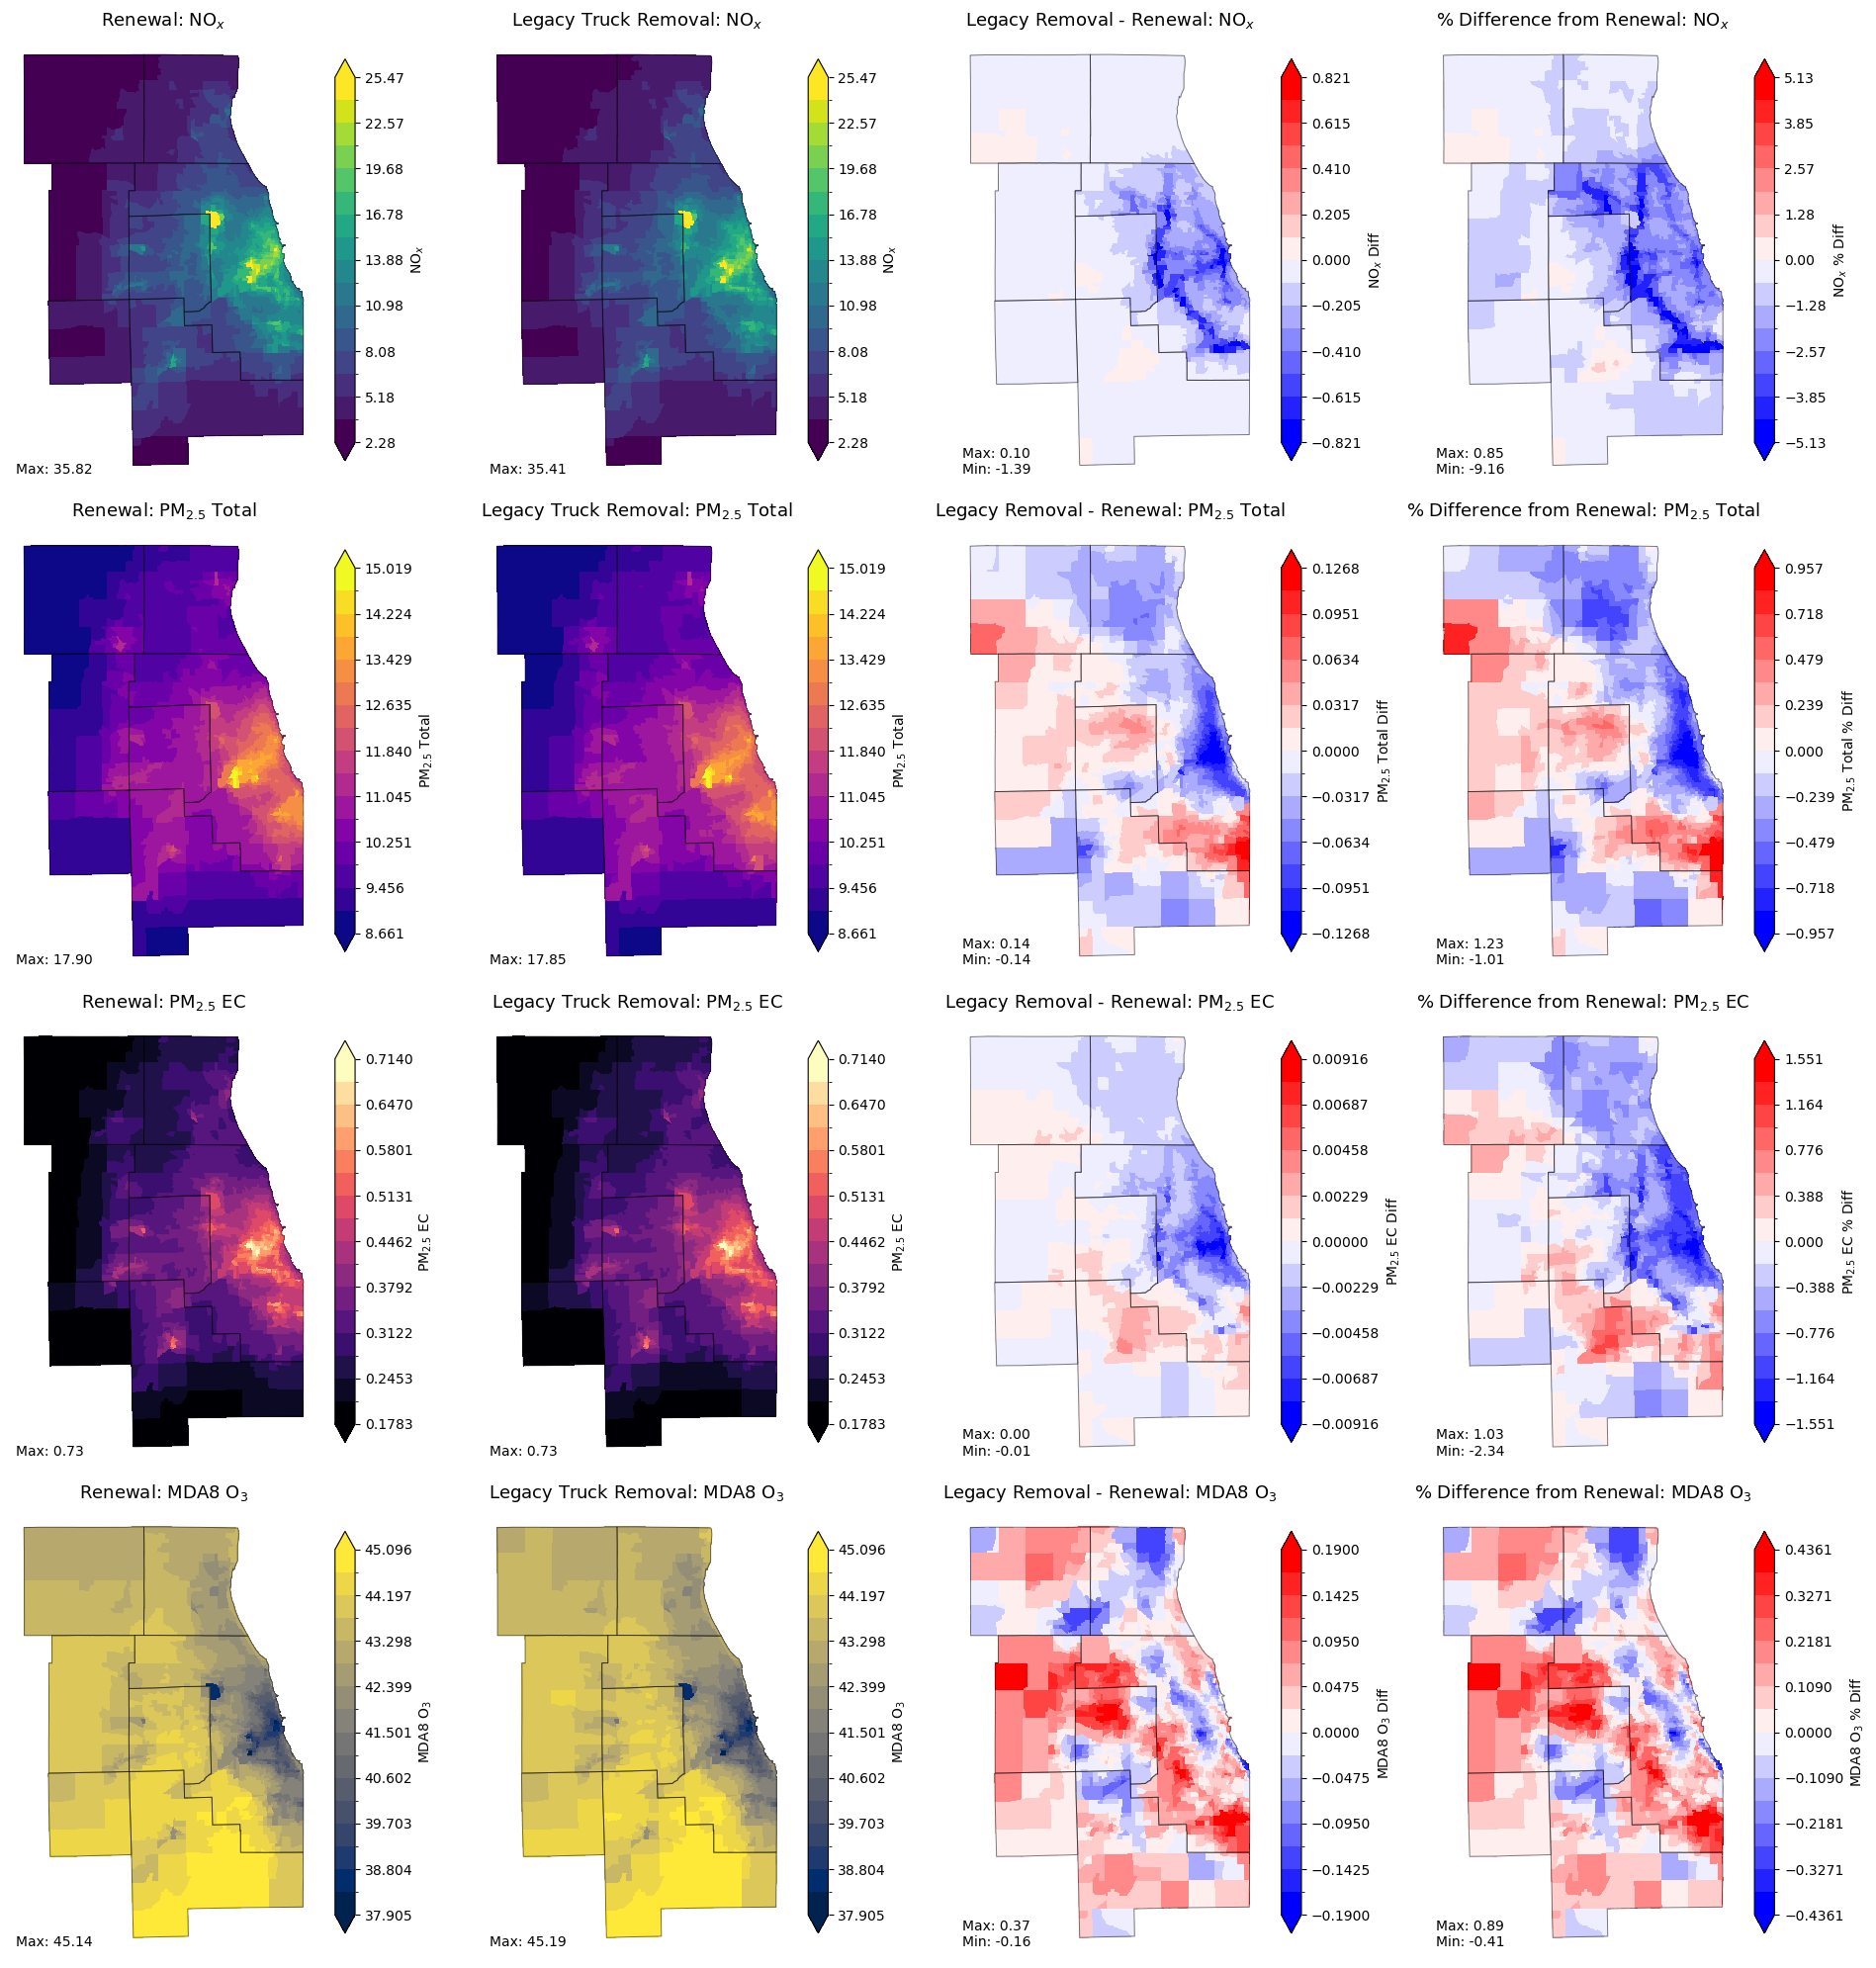

In [47]:
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs

N_BINS = 16

plot_config = {
    "NOX": {
        "cmap_name": "viridis",
        "title": "NO$_x$",
        "label": "NO$_x$",
        "reference_gdf": cmap_renewal,
        "scenario_gdf": cmap_zeropre2010s,
        "column": "NOX",
    },
    "PM25_TOT": {
        "cmap_name": "plasma",
        "title": "PM$_{2.5}$ Total",
        "label": "PM$_{2.5}$ Total",
        "reference_gdf": cmap_renewal,
        "scenario_gdf": cmap_zeropre2010s,
        "column": "PM25_TOT",
    },
    "PM25_EC": {
        "cmap_name": "magma",
        "title": "PM$_{2.5}$ EC",
        "label": "PM$_{2.5}$ EC",
        "reference_gdf": cmap_renewal,
        "scenario_gdf": cmap_zeropre2010s,
        "column": "PM25_EC",
    },
    "O3": {
        "cmap_name": "cividis",
        "title": "MDA8 O$_3$",
        "label": "MDA8 O$_3$",
        "reference_gdf": cmap_renewal_o3,
        "scenario_gdf": cmap_zeropre2010s_o3,
        "column": "O3",
    },
}

pollutants = ["NOX", "PM25_TOT", "PM25_EC", "O3"]

abs_styles = {}

for pol in pollutants:
    cfg = plot_config[pol]
    col = cfg["column"]

    vals_all = []

    for gdf in [cfg["reference_gdf"], cfg["scenario_gdf"]]:
        vals = gdf[col].astype(float).to_numpy()
        vals = vals[np.isfinite(vals)]
        vals_all.append(vals)

    vals_all = np.concatenate(vals_all)

    vmin = np.quantile(vals_all, 0.001)
    vmax = np.quantile(vals_all, 0.999)

    if np.isclose(vmin, vmax):
        vmax = vmin + 1e-6

    cmap_disc = ListedColormap(
        plt.cm.get_cmap(cfg["cmap_name"])(np.linspace(0, 1, N_BINS))
    )

    bounds = np.linspace(vmin, vmax, N_BINS + 1)
    norm = BoundaryNorm(bounds, cmap_disc.N)

    abs_styles[pol] = {
        "bounds": bounds,
        "cmap": cmap_disc,
        "norm": norm,
    }

diff_styles = {}

for pol in pollutants:
    cfg = plot_config[pol]
    col = cfg["column"]

    reference_vals = cfg["reference_gdf"][col].astype(float).to_numpy()
    scenario_vals = cfg["scenario_gdf"][col].astype(float).to_numpy()

    diff_vals = scenario_vals - reference_vals
    pct_vals = np.where(
        reference_vals != 0,
        (diff_vals / reference_vals) * 100.0,
        np.nan,
    )

    diff_vals_finite = diff_vals[np.isfinite(diff_vals)]
    pct_vals_finite = pct_vals[np.isfinite(pct_vals)]

    diff_lim = np.quantile(np.abs(diff_vals_finite), 0.99)
    pct_lim = np.quantile(np.abs(pct_vals_finite), 0.99)

    if np.isclose(diff_lim, 0):
        diff_lim = 1e-6
    if np.isclose(pct_lim, 0):
        pct_lim = 1e-6

    diff_bounds = np.linspace(-diff_lim, diff_lim, N_BINS + 1)
    pct_bounds = np.linspace(-pct_lim, pct_lim, N_BINS + 1)

    diff_cmap = ListedColormap(
        plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS))
    )

    pct_cmap = ListedColormap(
        plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS))
    )

    diff_styles[pol] = {
        "diff_bounds": diff_bounds,
        "diff_cmap": diff_cmap,
        "diff_norm": BoundaryNorm(diff_bounds, diff_cmap.N),
        "pct_bounds": pct_bounds,
        "pct_cmap": pct_cmap,
        "pct_norm": BoundaryNorm(pct_bounds, pct_cmap.N),
    }

scenario_names = [
    "Renewal",
    "Legacy Truck Removal",
    "Legacy Removal - Renewal",
    "% Difference from Renewal",
]

scenario_gdfs_by_pol = {}

for pol in pollutants:
    cfg = plot_config[pol]
    col = cfg["column"]

    plot_reference = cfg["reference_gdf"].copy()
    plot_scenario = cfg["scenario_gdf"].copy()
    plot_diff = cfg["scenario_gdf"].copy()
    plot_pct = cfg["scenario_gdf"].copy()

    plot_reference[pol] = plot_reference[col].astype(float)
    plot_scenario[pol] = plot_scenario[col].astype(float)

    plot_diff[pol] = (
        cfg["scenario_gdf"][col].astype(float)
        - cfg["reference_gdf"][col].astype(float)
    )

    plot_pct[pol] = np.where(
        cfg["reference_gdf"][col].astype(float) != 0,
        (
            (
                cfg["scenario_gdf"][col].astype(float)
                - cfg["reference_gdf"][col].astype(float)
            )
            / cfg["reference_gdf"][col].astype(float)
        )
        * 100.0,
        np.nan,
    )

    scenario_gdfs_by_pol[pol] = {
        scenario_names[0]: plot_reference,
        scenario_names[1]: plot_scenario,
        scenario_names[2]: plot_diff,
        scenario_names[3]: plot_pct,
    }

fig, axs = plt.subplots(
    nrows=len(pollutants),
    ncols=4,
    figsize=(20, 20),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

for i, pol in enumerate(pollutants):
    for j, scen in enumerate(scenario_names):
        ax = axs[i, j]
        gdf = scenario_gdfs_by_pol[pol][scen]

        if j in [0, 1]:
            style = abs_styles[pol]
            cmap_disc = style["cmap"]
            norm = style["norm"]
            bounds = style["bounds"]
        elif j == 2:
            style = diff_styles[pol]
            cmap_disc = style["diff_cmap"]
            norm = style["diff_norm"]
            bounds = style["diff_bounds"]
        else:
            style = diff_styles[pol]
            cmap_disc = style["pct_cmap"]
            norm = style["pct_norm"]
            bounds = style["pct_bounds"]

        gdf.plot(
            column=pol,
            ax=ax,
            cmap=cmap_disc,
            norm=norm,
            edgecolor="none",
            antialiased=False,
        )

        cmap_cty.boundary.plot(ax=ax, color="k", alpha=0.5, linewidth=0.7)

        ax.set_title(f"{scen}: {plot_config[pol]['title']}", fontsize=13)
        ax.set_axis_off()

        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_disc)
        sm._A = []

        cbar = fig.colorbar(
            sm,
            ax=ax,
            fraction=0.046,
            pad=0.04,
            boundaries=bounds,
            ticks=bounds[::2],
            spacing="proportional",
            extend="both",
        )

        if j == 3:
            cbar.set_label(f"{plot_config[pol]['label']} % Diff", fontsize=10)
        elif j == 2:
            cbar.set_label(f"{plot_config[pol]['label']} Diff", fontsize=10)
        else:
            cbar.set_label(plot_config[pol]["label"], fontsize=10)

        vals = gdf[pol].astype(float).to_numpy()
        vals = vals[np.isfinite(vals)]

        vmax_panel = float(np.nanmax(vals))
        vmin_panel = float(np.nanmin(vals))

        if j in [0, 1]:
            txt = f"Max: {vmax_panel:.2f}"
        else:
            txt = f"Max: {vmax_panel:.2f}\nMin: {vmin_panel:.2f}"

        ax.text(
            0.02,
            0.02,
            txt,
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=10,
            bbox=dict(
                facecolor="white",
                alpha=0.7,
                boxstyle="round,pad=0.25",
                linewidth=0,
            ),
        )

plt.tight_layout()
plt.show()